In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
from astropy import wcs
import glob
from lmfit import Minimizer, Parameters, report_fit

import lmfit
from lmfit.lineshapes import gaussian2d, lorentzian


from matplotlib.ticker import FormatStrFormatter
plt.rcParams['font.size'] = 35
plt.rcParams['axes.labelsize'] = 35
plt.rcParams['xtick.labelsize'] = 35
plt.rcParams['ytick.labelsize'] =35
plt.rcParams['legend.fontsize'] = 35
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.major.width'] = 5
plt.rcParams['ytick.major.width'] = 3
plt.rcParams['xtick.minor.width'] = 5
plt.rcParams['ytick.minor.width'] = 3

In [2]:
def residual(params, amp, amperr):
    height = params['height']
    x = params['x']
    y = params['y']
    sigma = params['sigma']
    
    xpix,ypix = np.meshgrid(np.arange(amp.shape[1]),np.arange(amp.shape[0]))
    
    model = height*np.exp(-(((x-xpix)/sigma)**2+((y-ypix)/sigma)**2)/2)
    
    return (amp-model) / amperr

In [3]:
def gauss_fitter(amp,amperr,plot_gass=False):
    params = Parameters()
    yo_guess, xo_guess = np.unravel_index(np.argmax(amp), amp.shape)
    sigma_x_guess, sigma_y_guess = 2.0, 2.0  # Initial guess for sigma
    params.add('height', value=np.max(amp))
    params.add('x', value=xo_guess, min=xo_guess-0.1, max=xo_guess+0.1) #estimated from looking at the amp values
    params.add('y', value=yo_guess, min=yo_guess-0.1, max=yo_guess+0.1)
    params.add('sigma', value=1,min=0.1, max=3)
    minner = Minimizer(residual, params, fcn_args=(amp, amperr))
    result = minner.minimize()
    
    fit = result.params.valuesdict()
    if plot_gass==True:
        report_fit(result)
        plt.figure(figsize=[12,12])
        xpix,ypix = np.meshgrid(np.linspace(0,amp.shape[0],60),np.linspace(0,amp.shape[1],60))
        bestfit = fit["height"]*np.exp(-(((fit["x"]-xpix)/fit["sigma"])**2+((fit["y"]-ypix)/fit["sigma"])**2)/2)
        plt.contour(xpix,ypix,bestfit,colors='0')
        plt.scatter(xo_guess, yo_guess,c='w',s=200)
        plt.imshow(np.log10(amp/np.max(amp)),origin='lower')
        plt.show()
    return fit["x"],fit["y"]

In [4]:
def pos_dif(file,j,plot_gass=False):
    cube_hdulist = fits.open(file)

    nw = cube_hdulist[1].shape[0]

    cube_data = cube_hdulist[1].data
    w = wcs.WCS(cube_hdulist[1].header)
    hdr = cube_hdulist[1].header
    wave = (np.arange(nw) + hdr["CRPIX3"]) * hdr["CDELT3"] + hdr["CRVAL3"]


    amp=[]
    xa=[]
    ya=[]
    sigx=[]
    sigy=[]
    ww=[]
    wave=wave[0:np.shape(cube_data)[0]]


    i=0
    while i<np.shape(cube_data)[0]:
        # Fit Gaussian to the central region of the cube
        z_index = i#np.shape(cube_data)[0] // 2  # Choose central spectral channel
        amp = np.mean(cube_data[z_index:z_index+j],axis=0)
        amperr=np.std(cube_data[z_index:z_index+j],axis=0)
        amp[np.isnan(amp)]=1e-10
        amp[amp<np.max(amp)*0.05]=1e-10
        amperr[np.isnan(amperr)]=1e-10
        x1,y1=gauss_fitter(amp,amperr,plot_gass)
        a=w.pixel_to_world(x1,y1,0)[0]
        #print((a.ra).deg,(a.dec).deg,np.mean(wave[z_index:z_index+j]))
        
        xa.append((a.ra).deg)
        ya.append((a.dec).deg)
        ww.append(np.mean(wave[z_index:z_index+j]))
        i=i+(j//3)
    xa=np.array(xa)
    ya=np.array(ya)
    ww=np.array(ww)

    x1=np.percentile(xa,25)
    x2=np.percentile(xa,75)

    ya=ya[(x1<xa) & (xa<x2)]
    ww=ww[(x1<xa) & (xa<x2)]
    xa=xa[(x1<xa) & (xa<x2)]

    plt.figure(figsize=[12,12])
    plt.scatter(ww,(xa-np.mean(xa))*3600,label='RA',s=100,c='b')
    plt.scatter(ww,(ya-np.mean(ya))*3600,label='Dec',s=100,c='orange')
    plt.legend()
    plt.ylim(-0.3,0.3)
    plt.xlabel('Wavelength ($\mu$m)')
    plt.ylabel('Offset from mean (arcsec)')
        
        
    print("In "+ str(file) + " the mean RA is " + str(np.mean(xa))+ " degs and mean Dec is "+ str(np.mean(ya))+ ' degs with mean\
          wavelength in mircons '+ str(np.mean(ww)))
    return np.mean(xa),np.mean(ya),np.mean(ww)

       

<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_94636/1183371509.py:54: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Wavelength ($\mu$m)')


[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 90
    # data points      = 3591
    # variables        = 4
    chi-square         = 446966.281
    reduced chi-square = 124.607271
    Akaike info crit   = 17331.1723
    Bayesian info crit = 17355.9171
[[Variables]]
    height:  133.187568 +/- 9.50589610 (7.14%) (init = 143.3974)
    x:       28.9000002 +/- 0.17486521 (0.61%) (init = 29)
    y:       26.9949769 +/- 0.17198124 (0.64%) (init = 27)
    sigma:   3.00000000 +/- 1.95639299 (65.21%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = -0.6946
    C(height, y)     = -0.1967
    C(y, sigma)      = +0.1701


Set DATE-AVG to '2022-07-23T07:06:04.270' from MJD-AVG.
Set DATE-END to '2022-07-23T08:00:19.331' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.860883 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724561055.615 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


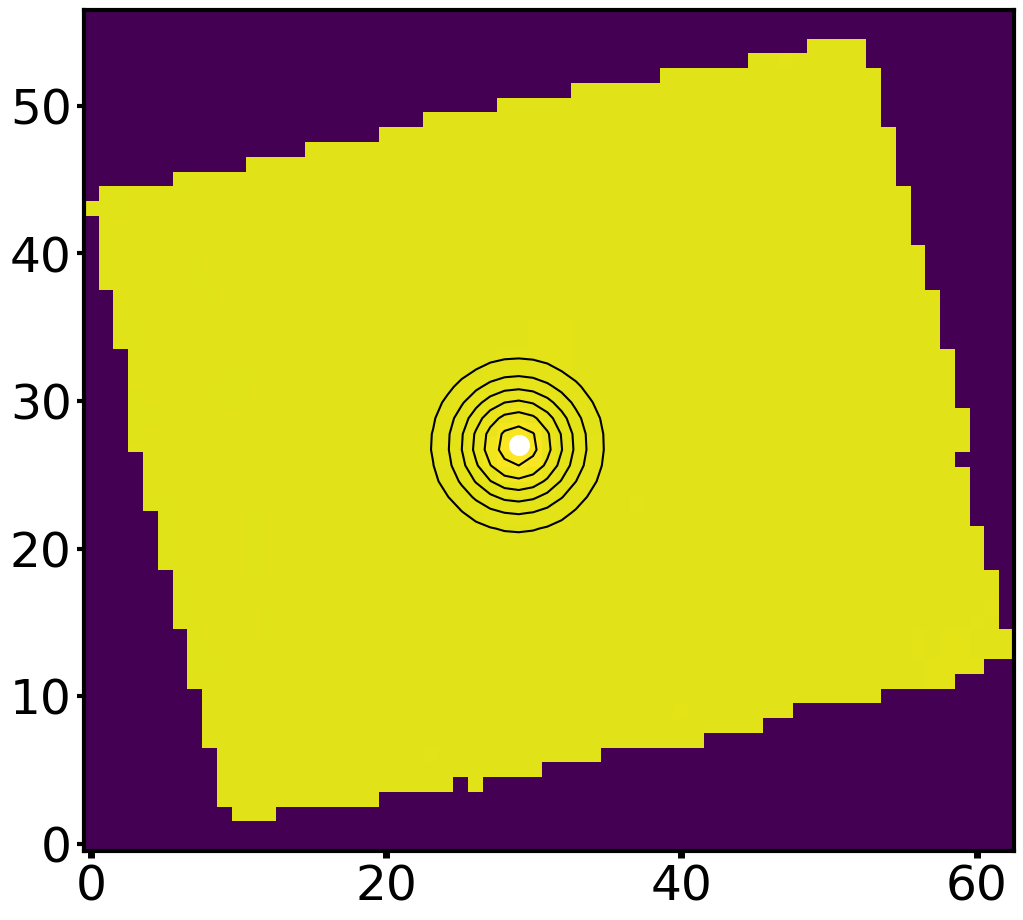

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 75
    # data points      = 3591
    # variables        = 4
    chi-square         = 545062.817
    reduced chi-square = 151.955065
    Akaike info crit   = 18043.6910
    Bayesian info crit = 18068.4357
[[Variables]]
    height:  136.574554 +/- 9.19351353 (6.73%) (init = 154.3626)
    x:       28.9000000 +/- 0.07743463 (0.27%) (init = 29)
    y:       26.9000010 +/- 0.08089845 (0.30%) (init = 27)
    sigma:   2.99999997 +/- 0.04022282 (1.34%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = -0.6577
    C(height, y)     = +0.2749
    C(y, sigma)      = -0.2552
    C(height, x)     = +0.1241


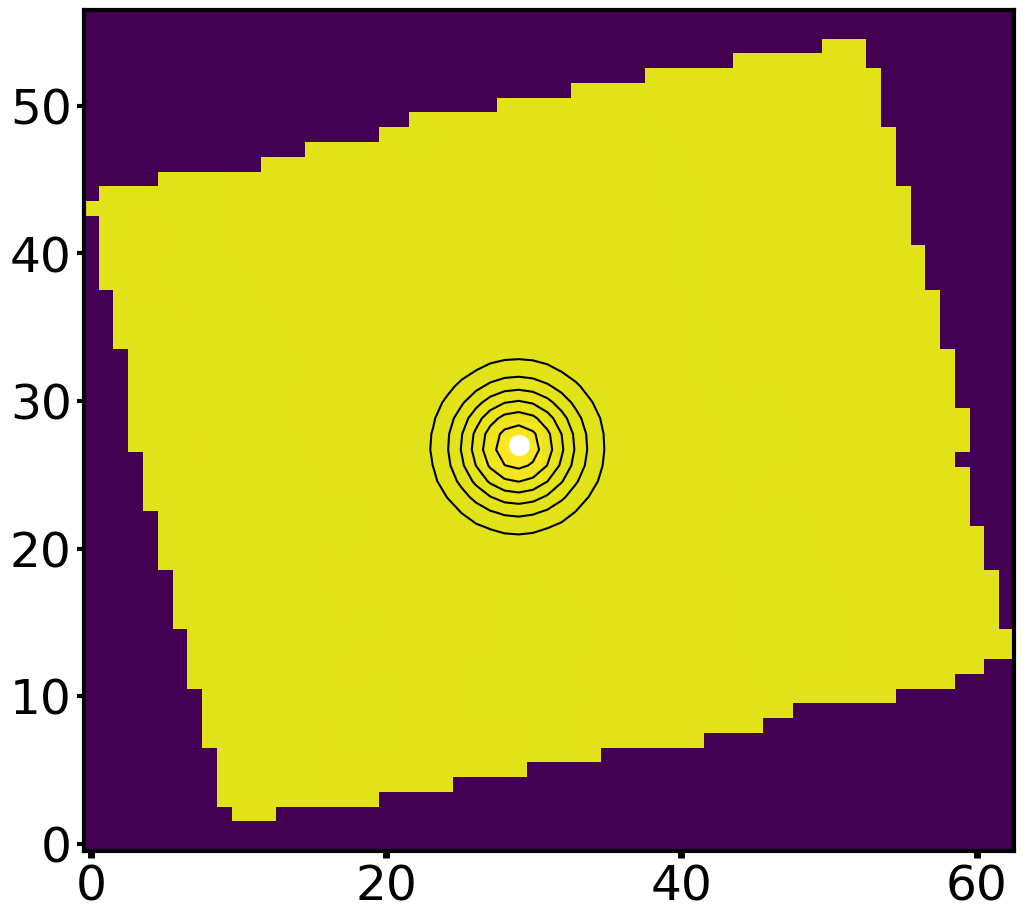

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 84
    # data points      = 3591
    # variables        = 4
    chi-square         = 514789.590
    reduced chi-square = 143.515358
    Akaike info crit   = 17838.4912
    Bayesian info crit = 17863.2359
[[Variables]]
    height:  149.556443 +/- 9.94706459 (6.65%) (init = 165.486)
    x:       28.9943269 +/- 0.17091728 (0.59%) (init = 29)
    y:       26.9000001 +/- 0.09967307 (0.37%) (init = 27)
    sigma:   3.00000000 +/- 0.01401352 (0.47%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = +0.6195
    C(y, sigma)      = -0.2987
    C(height, y)     = -0.2476


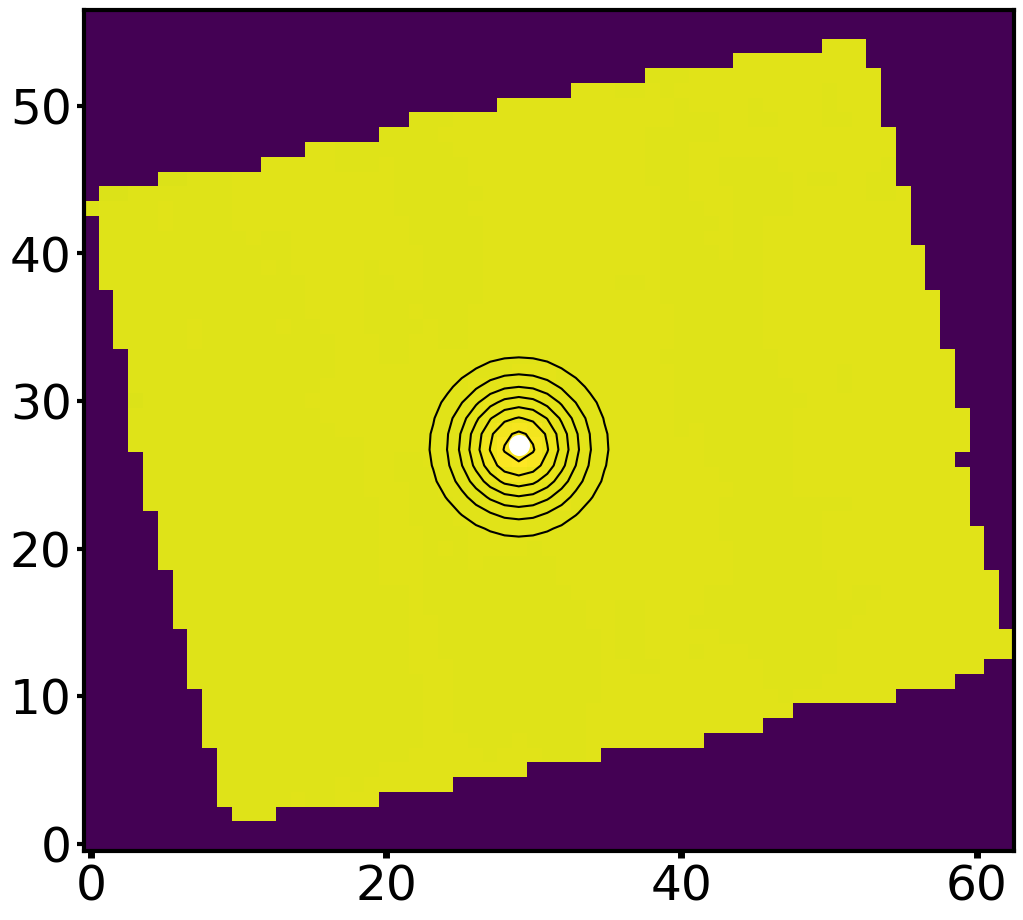

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 80
    # data points      = 3591
    # variables        = 4
    chi-square         = 553647.648
    reduced chi-square = 154.348382
    Akaike info crit   = 18099.8090
    Bayesian info crit = 18124.5538
[[Variables]]
    height:  154.447893 +/- 10.2614229 (6.64%) (init = 173.3314)
    x:       29.0339219 +/- 0.17048812 (0.59%) (init = 29)
    y:       26.9257607 +/- 0.17648977 (0.66%) (init = 27)
    sigma:   3.00000000 +/- 0.01675049 (0.56%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = +0.6244
    C(y, sigma)      = -0.2657
    C(height, y)     = -0.2578


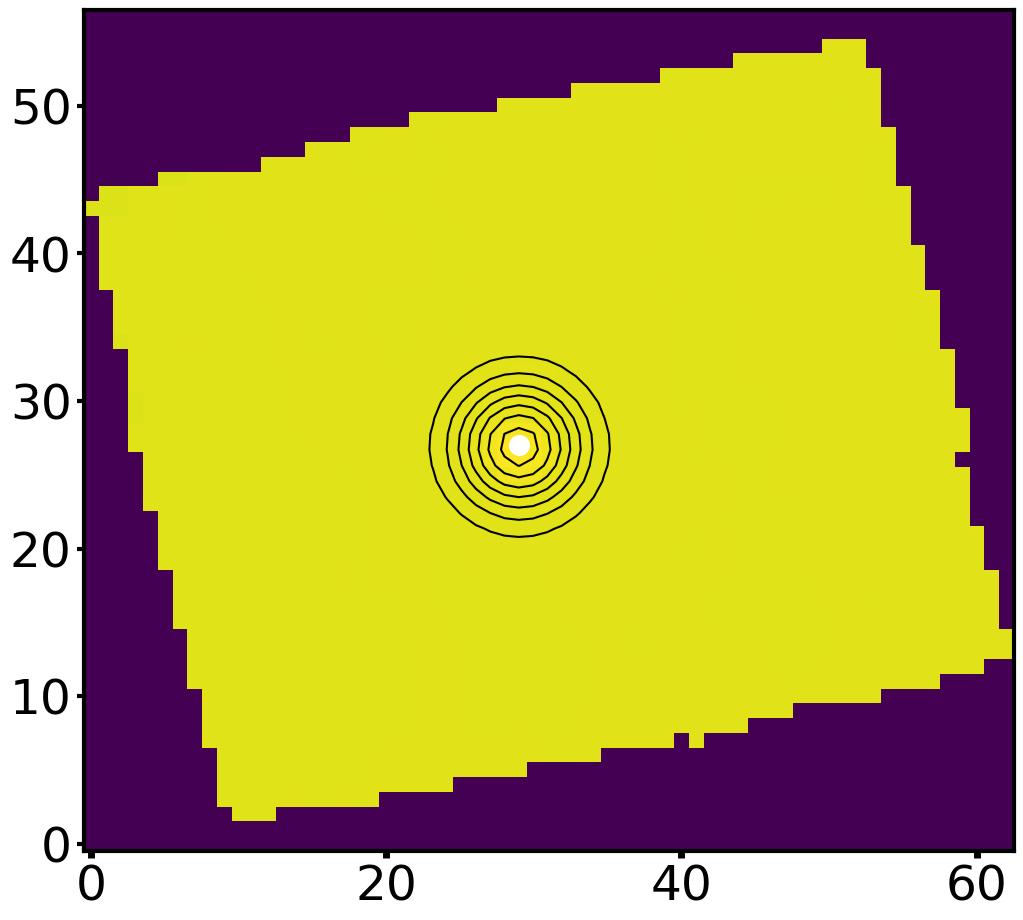

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 67
    # data points      = 3591
    # variables        = 4
    chi-square         = 583931.247
    reduced chi-square = 162.790981
    Akaike info crit   = 18291.0469
    Bayesian info crit = 18315.7917
[[Variables]]
    height:  171.536642 +/- 11.9259118 (6.95%) (init = 149.5109)
    x:       28.9375208 +/- 0.13506011 (0.47%) (init = 29)
    y:       26.9642680 +/- 0.14992578 (0.56%) (init = 27)
    sigma:   2.99999999 +/- 0.07120557 (2.37%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = -0.7357
    C(y, sigma)      = +0.2229
    C(height, y)     = -0.1979


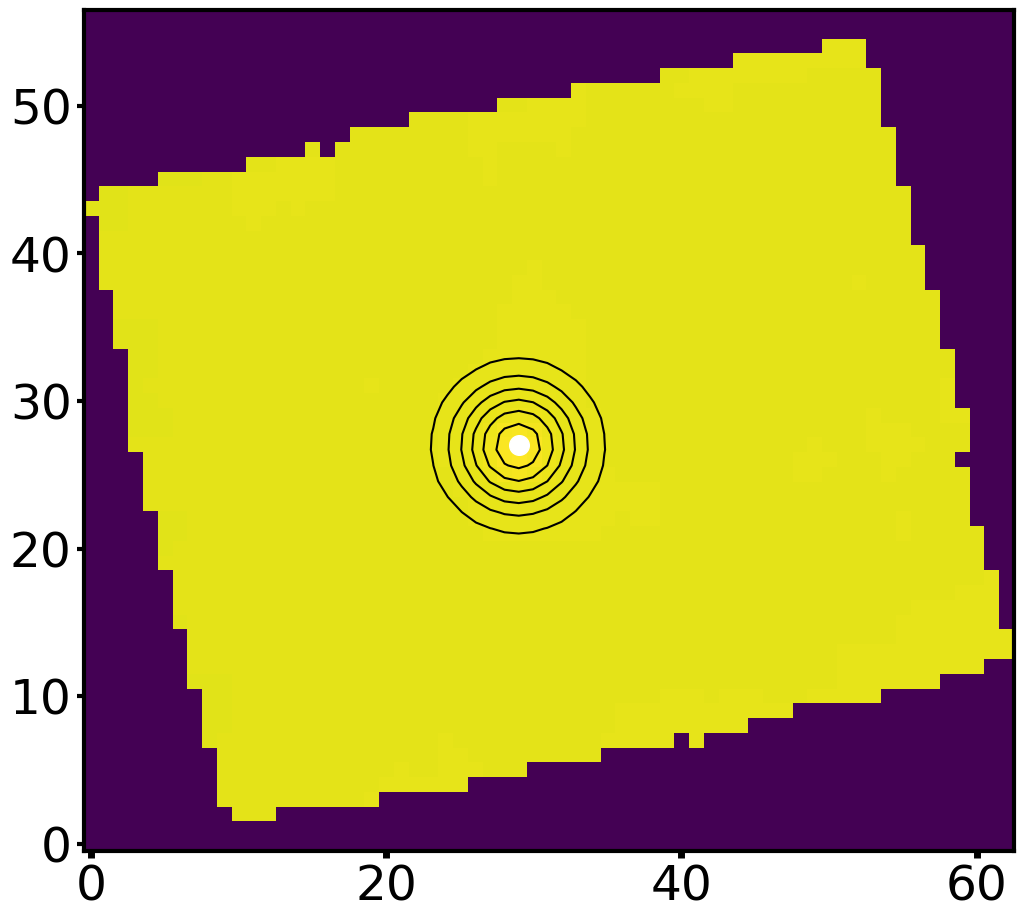

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 73
    # data points      = 3591
    # variables        = 4
    chi-square         = 510557.145
    reduced chi-square = 142.335418
    Akaike info crit   = 17808.8450
    Bayesian info crit = 17833.5898
[[Variables]]
    height:  172.103869 +/- 11.2575480 (6.54%) (init = 114.8571)
    x:       28.9246543 +/- 0.13997018 (0.48%) (init = 29)
    y:       26.9000000 +/- 19.1570792 (71.22%) (init = 27)
    sigma:   3.00000000 +/- 0.01317021 (0.44%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = +0.6808
    C(y, sigma)      = -0.2800
    C(height, y)     = -0.1821


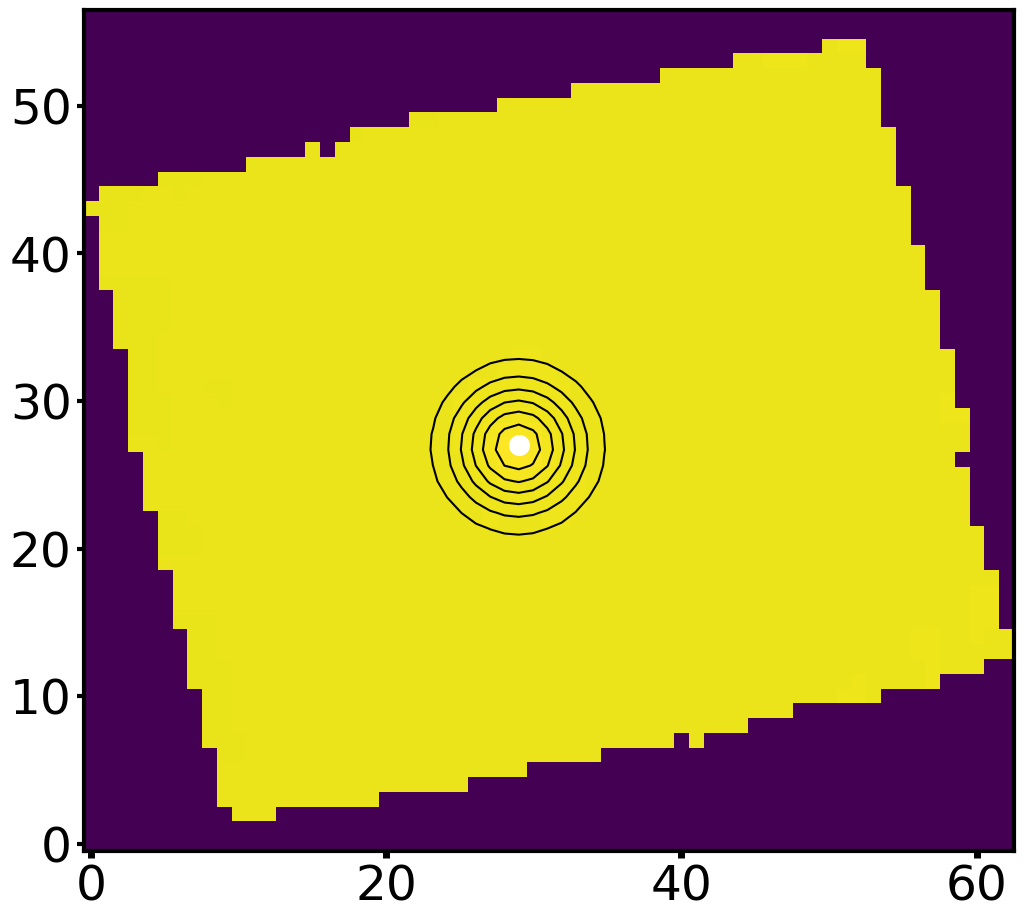

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 74
    # data points      = 3591
    # variables        = 4
    chi-square         = 456819.988
    reduced chi-square = 127.354332
    Akaike info crit   = 17409.4786
    Bayesian info crit = 17434.2233
[[Variables]]
    height:  162.591971 +/- 11.8451112 (7.29%) (init = 89.48778)
    x:       28.9920455 +/- 0.19504105 (0.67%) (init = 29)
    y:       26.9000000 +/- 0.02284277 (0.08%) (init = 27)
    sigma:   3.00000000 +/- 0.02966330 (0.99%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = +0.5352
    C(y, sigma)      = +0.3779
    C(height, y)     = +0.1338


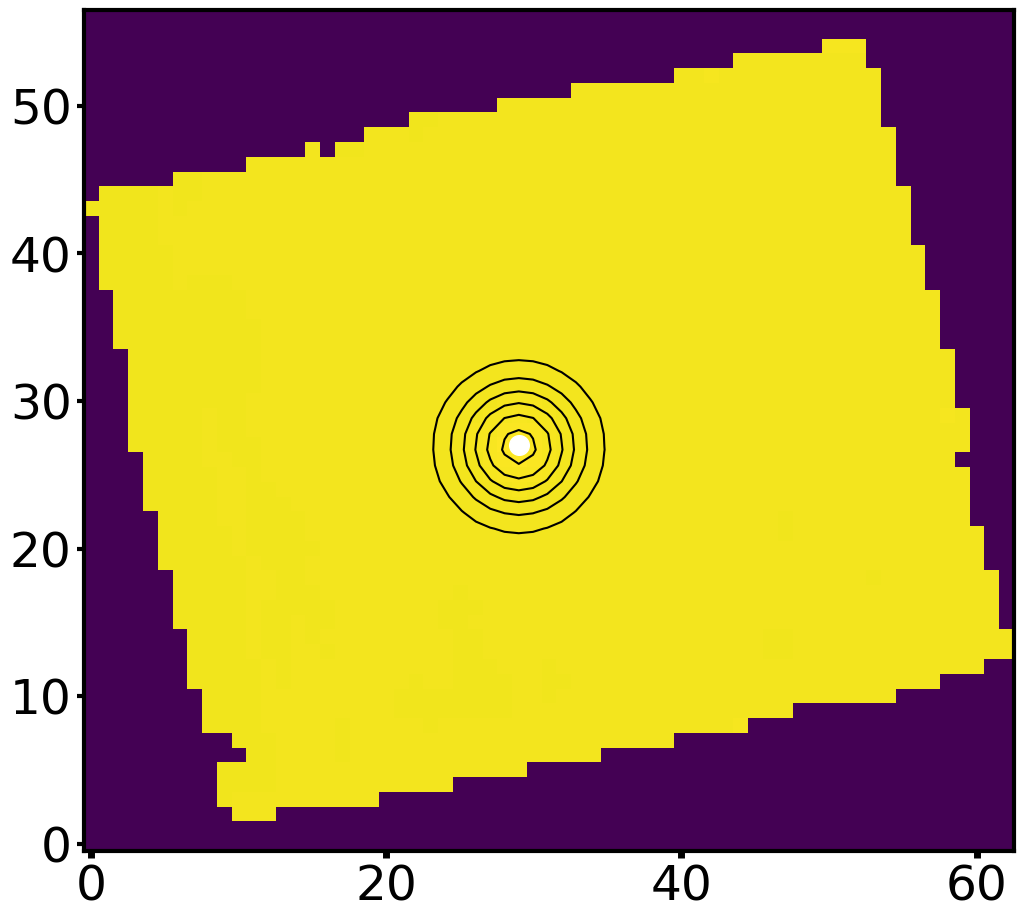

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 74
    # data points      = 3591
    # variables        = 4
    chi-square         = 654288.704
    reduced chi-square = 182.405549
    Akaike info crit   = 18699.5787
    Bayesian info crit = 18724.3234
[[Variables]]
    height:  180.240810 +/- 13.9781084 (7.76%) (init = 87.24703)
    x:       28.9669918 +/- 0.19153120 (0.66%) (init = 29)
    y:       26.9000015 +/- 0.11876469 (0.44%) (init = 27)
    sigma:   3.00000000 +/- 0.04877245 (1.63%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = +0.5744
    C(y, sigma)      = -0.3479
    C(height, y)     = -0.1312


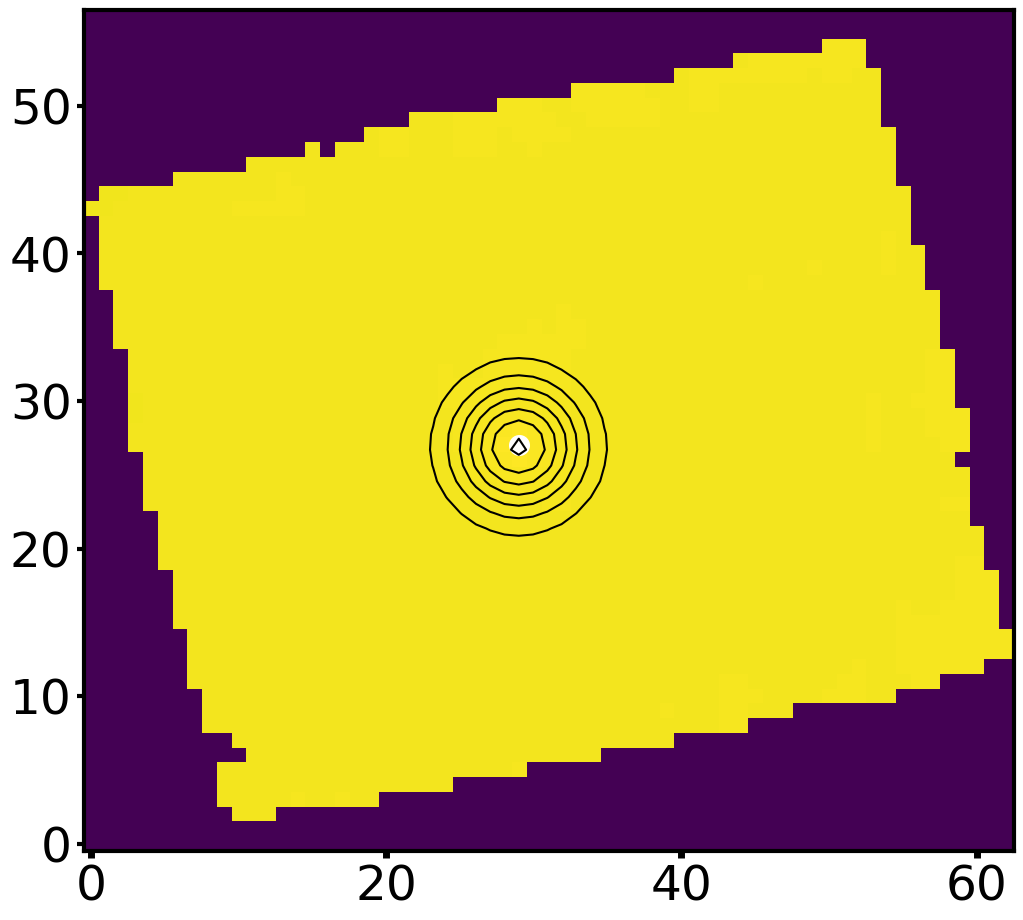

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 89
    # data points      = 3591
    # variables        = 4
    chi-square         = 955674.153
    reduced chi-square = 266.427141
    Akaike info crit   = 20060.0948
    Bayesian info crit = 20084.8395
[[Variables]]
    height:  169.466120 +/- 12.6666896 (7.47%) (init = 103.6351)
    x:       28.9000050 +/- 0.06445277 (0.22%) (init = 29)
    y:       26.9206198 +/- 0.16528840 (0.61%) (init = 27)
    sigma:   2.99999998 +/- 0.22507895 (7.50%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(height, sigma) = +0.7536
    C(y, sigma)      = -0.1453
    C(height, y)     = -0.1398


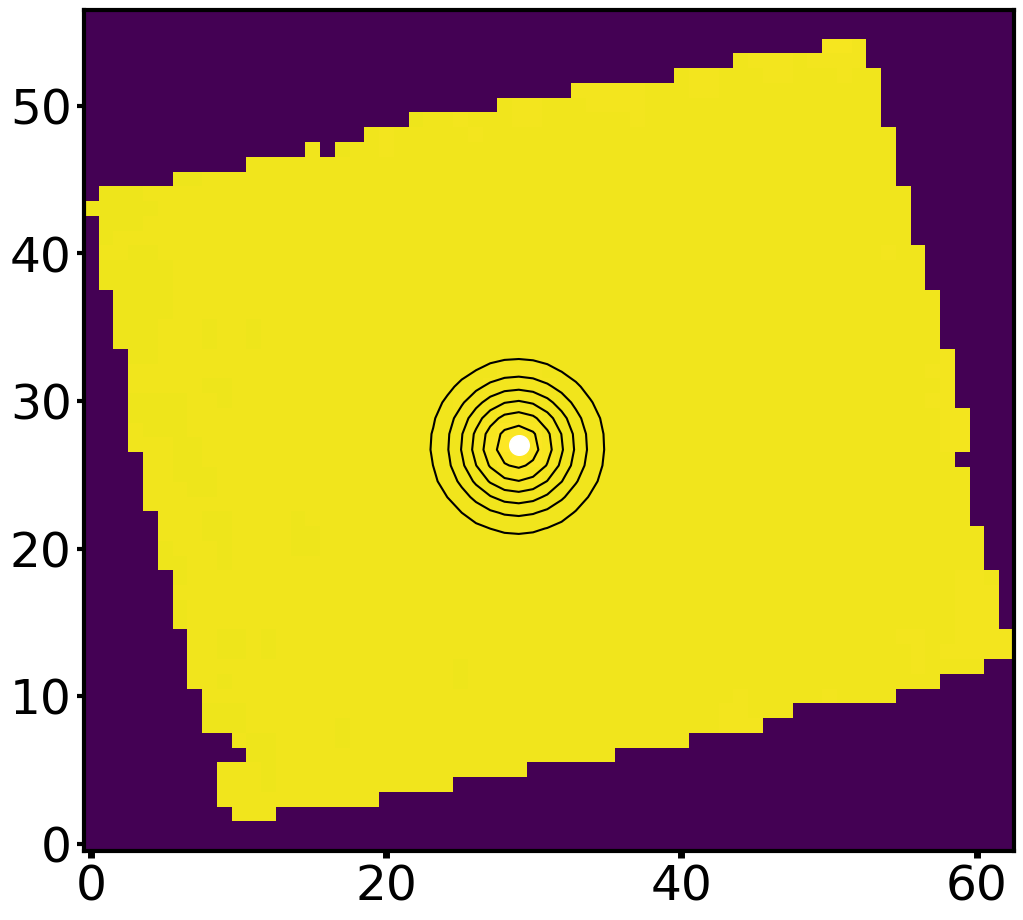

In Level3_ch3-medium_wcs1_s3d.fits the mean RA is 247.09010379790047 degs and mean Dec is -24.60668415650727 degs with mean          wavelength in mircons 15.005833448686944


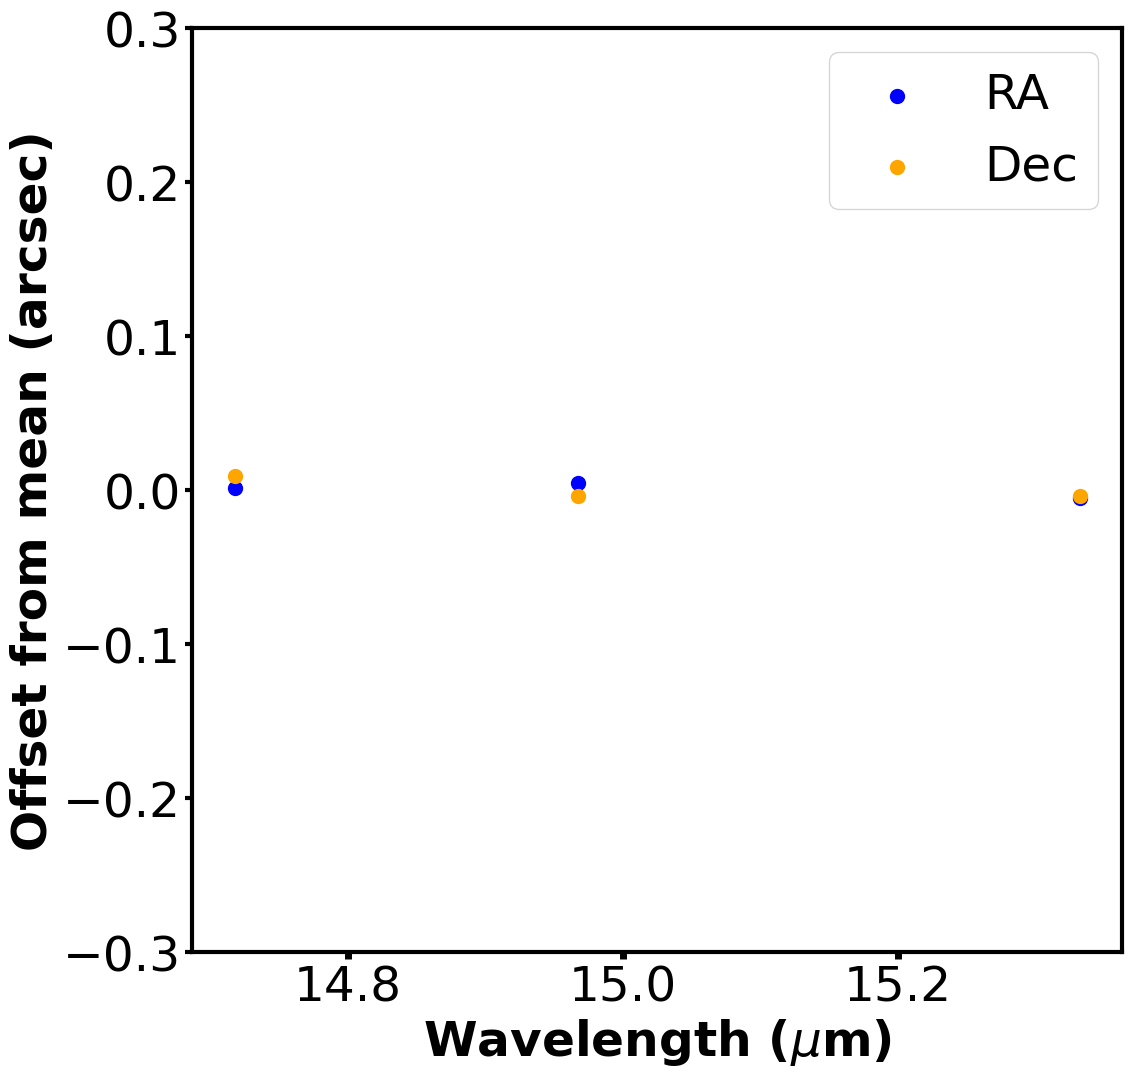

In [5]:
xa,ya,ww=pos_dif('Level3_ch3-medium_wcs1_s3d.fits',300,plot_gass=True)




Level3_ch3-medium_wcs1_s3d.fits


Set DATE-AVG to '2022-07-23T07:06:04.270' from MJD-AVG.
Set DATE-END to '2022-07-23T08:00:19.331' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.860883 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724561055.615 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In Level3_ch3-medium_wcs1_s3d.fits the mean RA is 247.0901026224966 degs and mean Dec is -24.606679285336597 degs with mean          wavelength in mircons 14.863437618536405
Level3_ch4-short_wcs1_s3d.fits
In Level3_ch4-short_wcs1_s3d.fits the mean RA is 247.09010832697777 degs and mean Dec is -24.60674328340023 degs with mean          wavelength in mircons 19.531200778856874


Set DATE-AVG to '2022-07-23T05:12:08.601' from MJD-AVG.
Set DATE-END to '2022-07-23T06:06:26.634' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.876066 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724775587.000 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-07-23T07:06:05.538' from MJD-AVG.
Set DATE-END to '2022-07-23T08:00:07.171' from MJD-END'. [astropy.wcs.wcs]


Level3_ch2-medium_wcs1_s3d.fits
In Level3_ch2-medium_wcs1_s3d.fits the mean RA is 247.08922915832707 degs and mean Dec is -24.606616336445384 degs with mean          wavelength in mircons 9.594418260628697
Level3_ch3-long_wcs1_s3d.fits


...

In Level3_ch1-short_wcs1_s3d.fits the mean RA is nan degs and mean Dec is nan degs with mean          wavelength in mircons nan
Level3_ch2-short_wcs1_s3d.fits
In Level3_ch2-short_wcs1_s3d.fits the mean RA is 247.09009484065712 degs and mean Dec is -24.60670626510061 degs with mean          wavelength in mircons 7.9915780079706265
Level3_ch3-short_wcs1_s3d.fits
In Level3_ch3-short_wcs1_s3d.fits the mean RA is 247.09010668567336 degs and mean Dec is -24.60671565146739 degs with mean          wavelength in mircons 12.983281408698527
Level3_ch1-long_wcs1_s3d.fits


Set DATE-AVG to '2022-07-23T08:59:08.944' from MJD-AVG.
Set DATE-END to '2022-07-23T09:53:35.932' from MJD-END'. [astropy.wcs.wcs]


In Level3_ch1-long_wcs1_s3d.fits the mean RA is 247.09010334675114 degs and mean Dec is -24.606709830482192 degs with mean          wavelength in mircons 7.1268001947319135
jw01802-o015_t012_nirspec_g395m-f290lp_crop1_wcs1_s3d.fits


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set DATE-AVG to '2022-07-22T15:59:31.919' from MJD-AVG.
Set DATE-END to '2022-07-22T17:16:15.735' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.965746 from OBSGEO-[XYZ].
Set OBSGEO-H to 1726065897.713 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In jw01802-o015_t012_nirspec_g395m-f290lp_crop1_wcs1_s3d.fits the mean RA is 247.09011179292526 degs and mean Dec is -24.606670849427807 degs with mean          wavelength in mircons 4.373561292629478
Level3_ch4-medium_wcs1_s3d.fits
In Level3_ch4-medium_wcs1_s3d.fits the mean RA is 247.09007105394284 degs and mean Dec is -24.606721279035558 degs with mean          wavelength in mircons 22.51520054992288
Level3_ch1-medium_wcs1_s3d.fits
In Level3_ch1-medium_wcs1_s3d.fits the mean RA is 247.0901019631062 degs and mean Dec is -24.60668739028043 degs with mean          wavelength in mircons 6.098981654504315
Level3_ch2-long_wcs1_s3d.fits
In Level3_ch2-long_wcs1_s3d.fits the mean RA is 247.09008133579462 degs and mean Dec is -24.60669623543895 degs with mean          wavelength in mircons 11.051300231716597
Level3_ch4-long_wcs1_s3d.fits
In Level3_ch4-long_wcs1_s3d.fits the mean RA is 247.09013688147158 degs and mean Dec is -24.60674009925372 degs with mean          wavelength in mircons 26.3

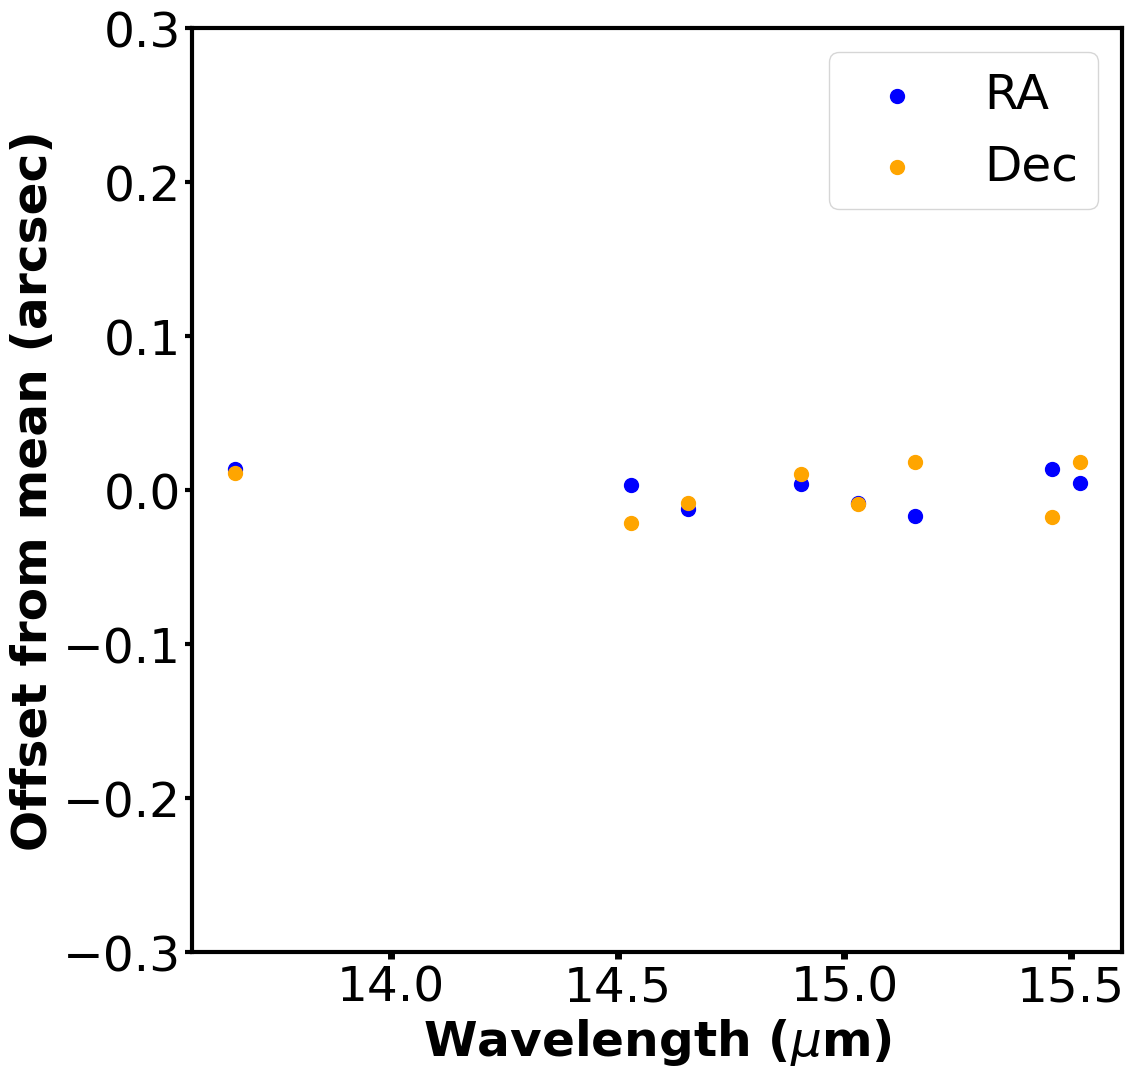

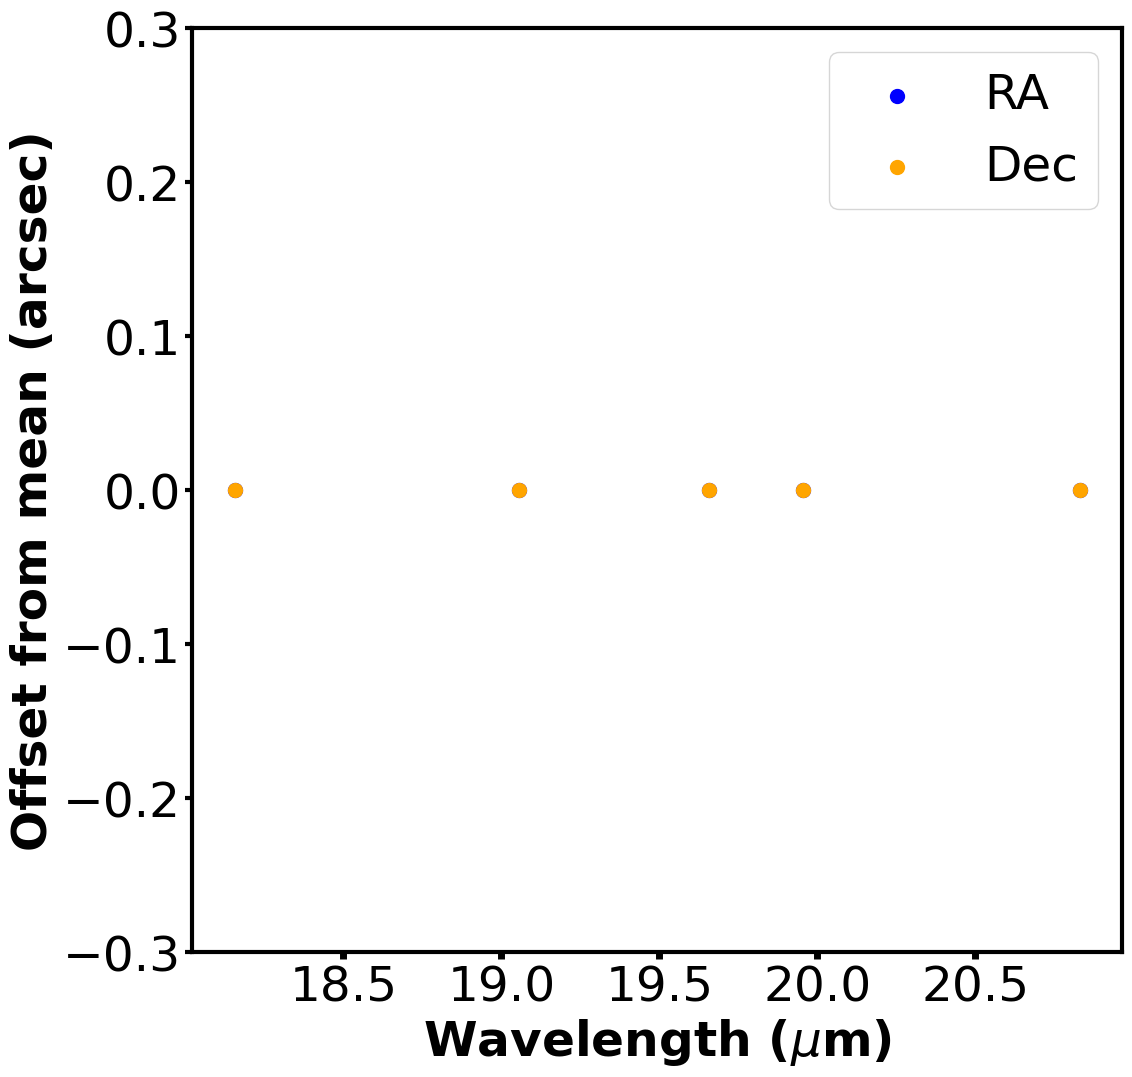

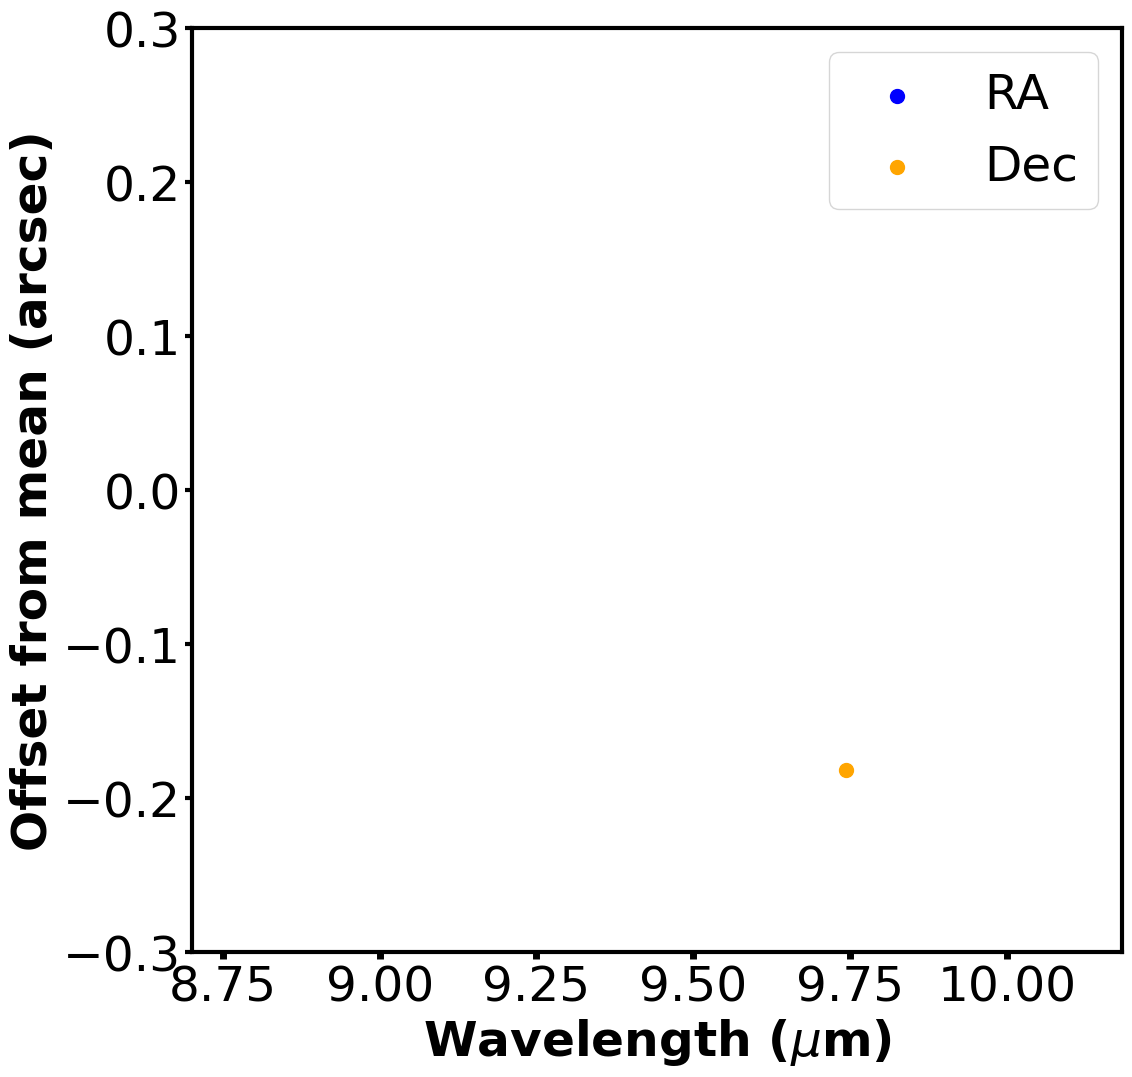

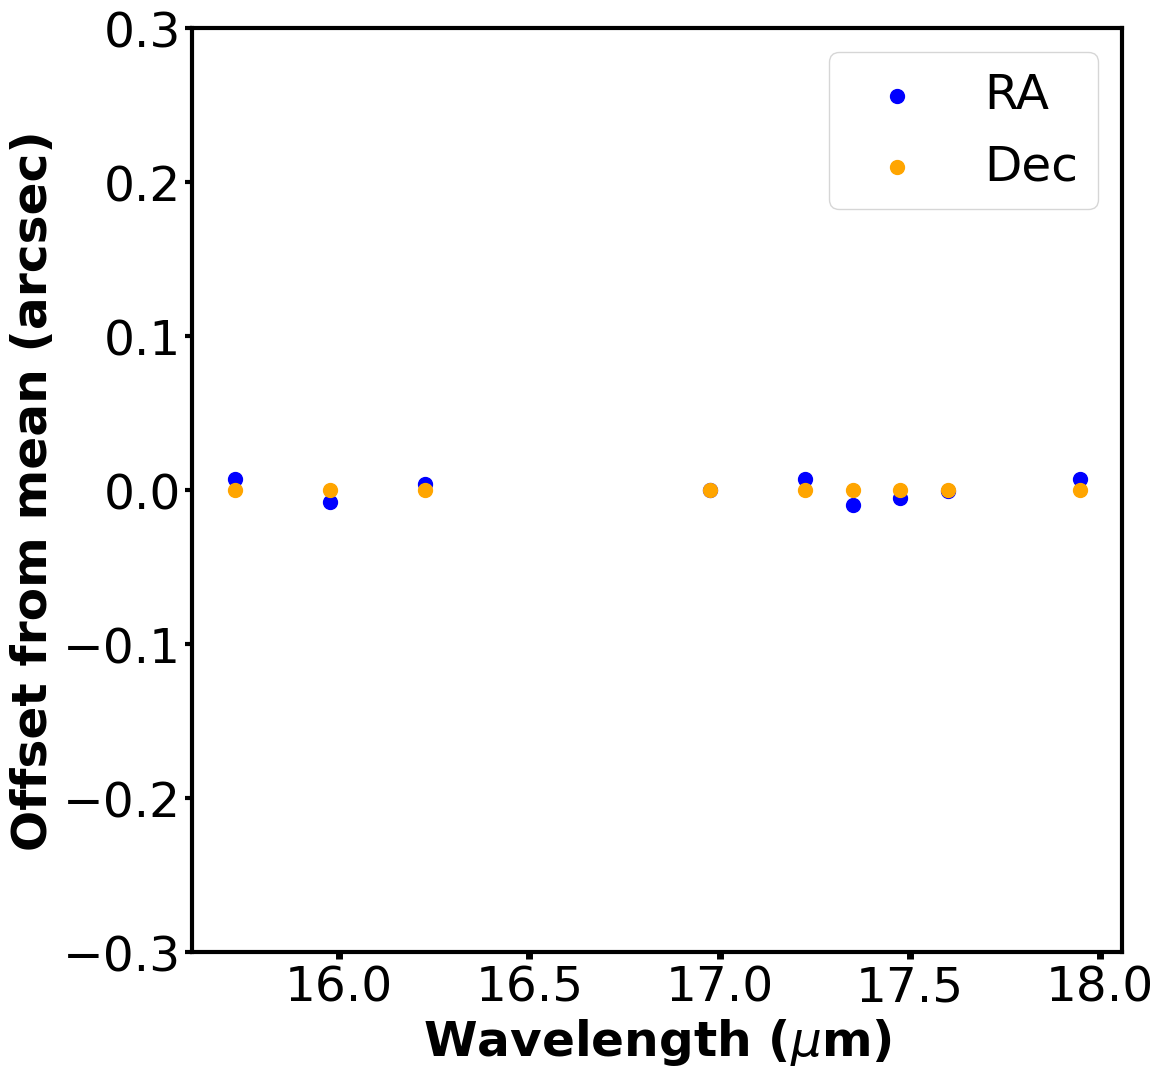

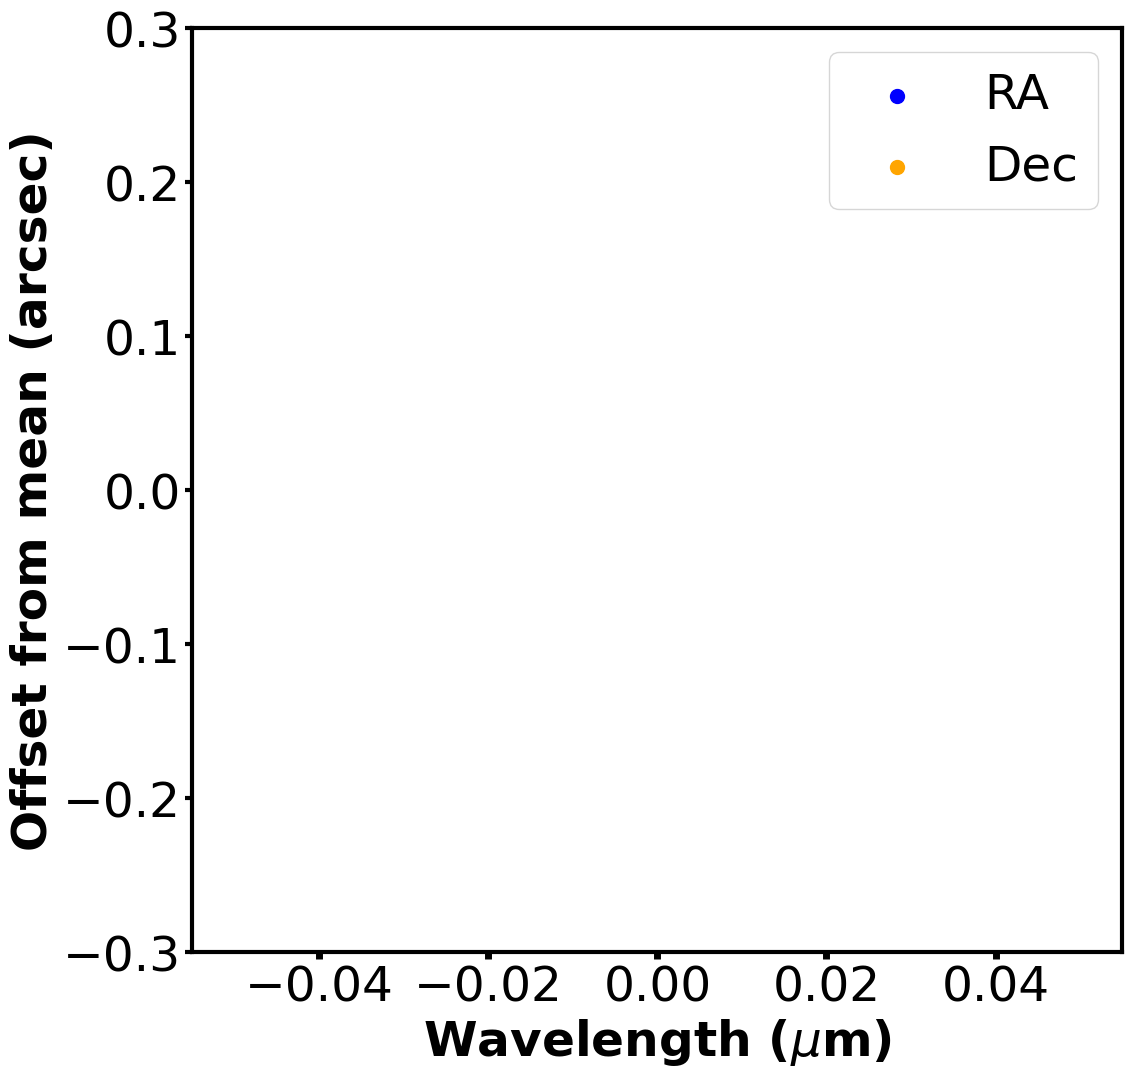

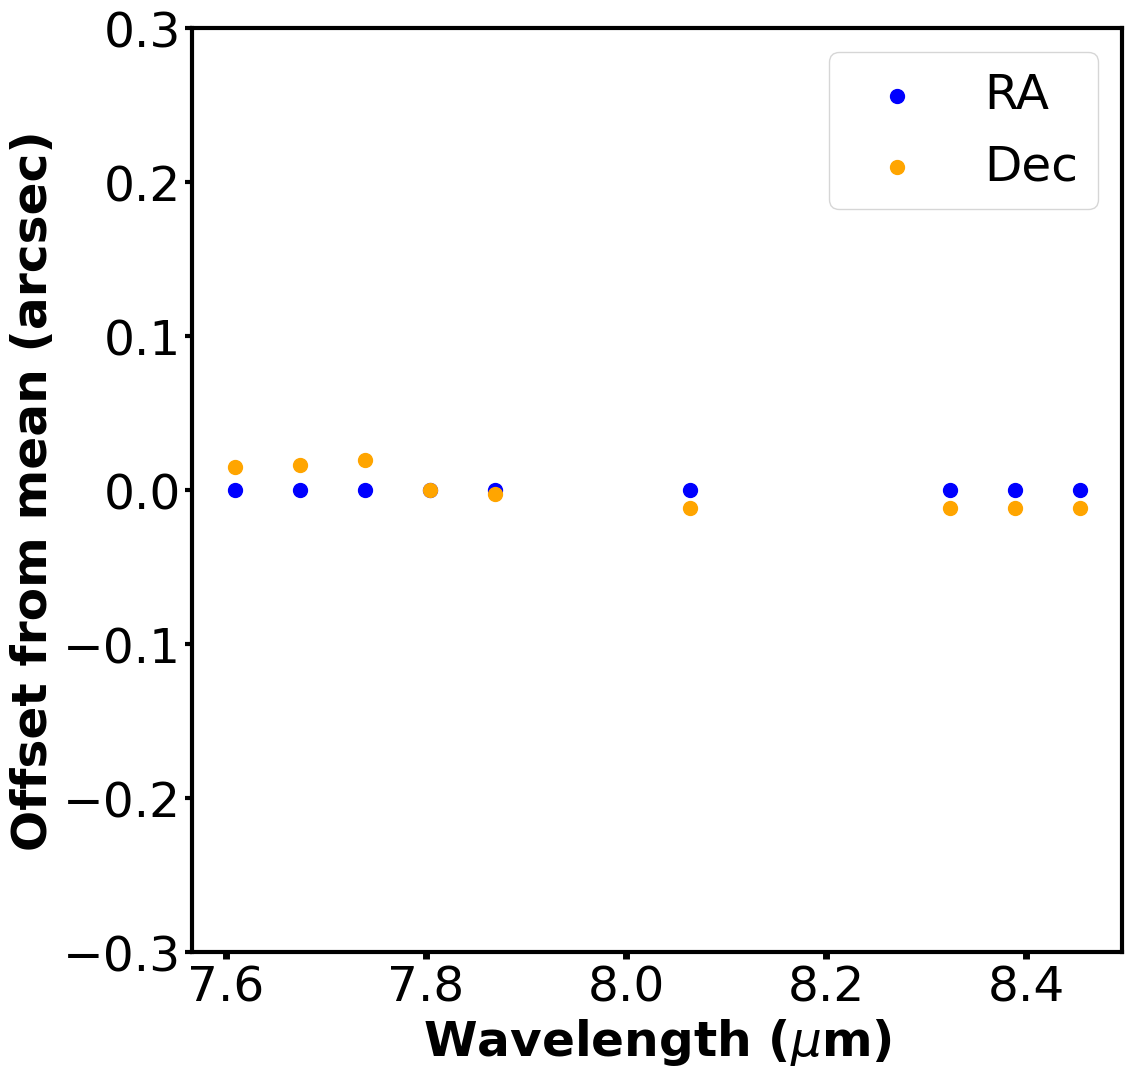

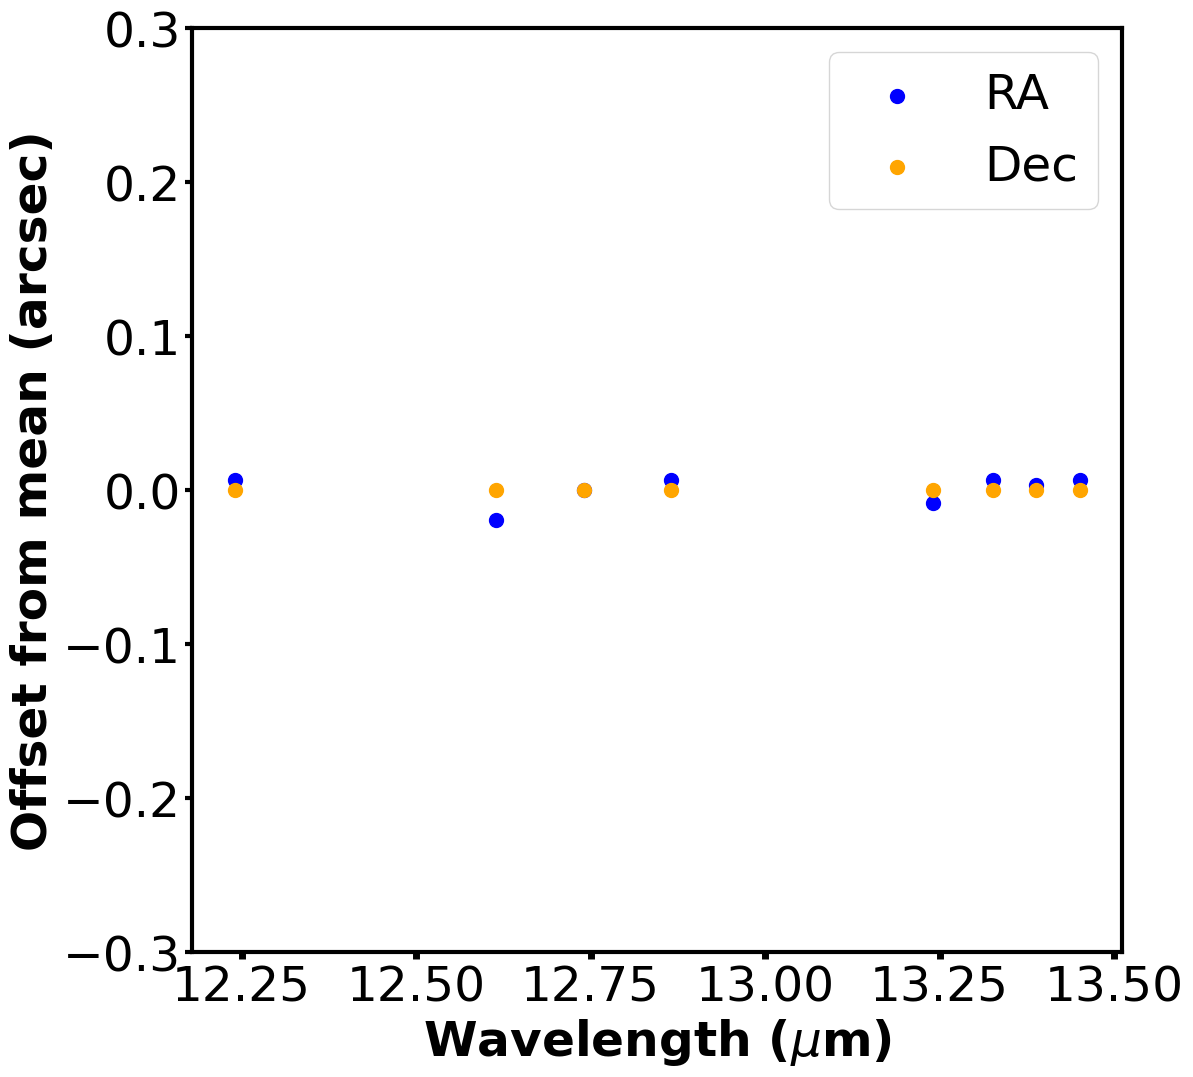

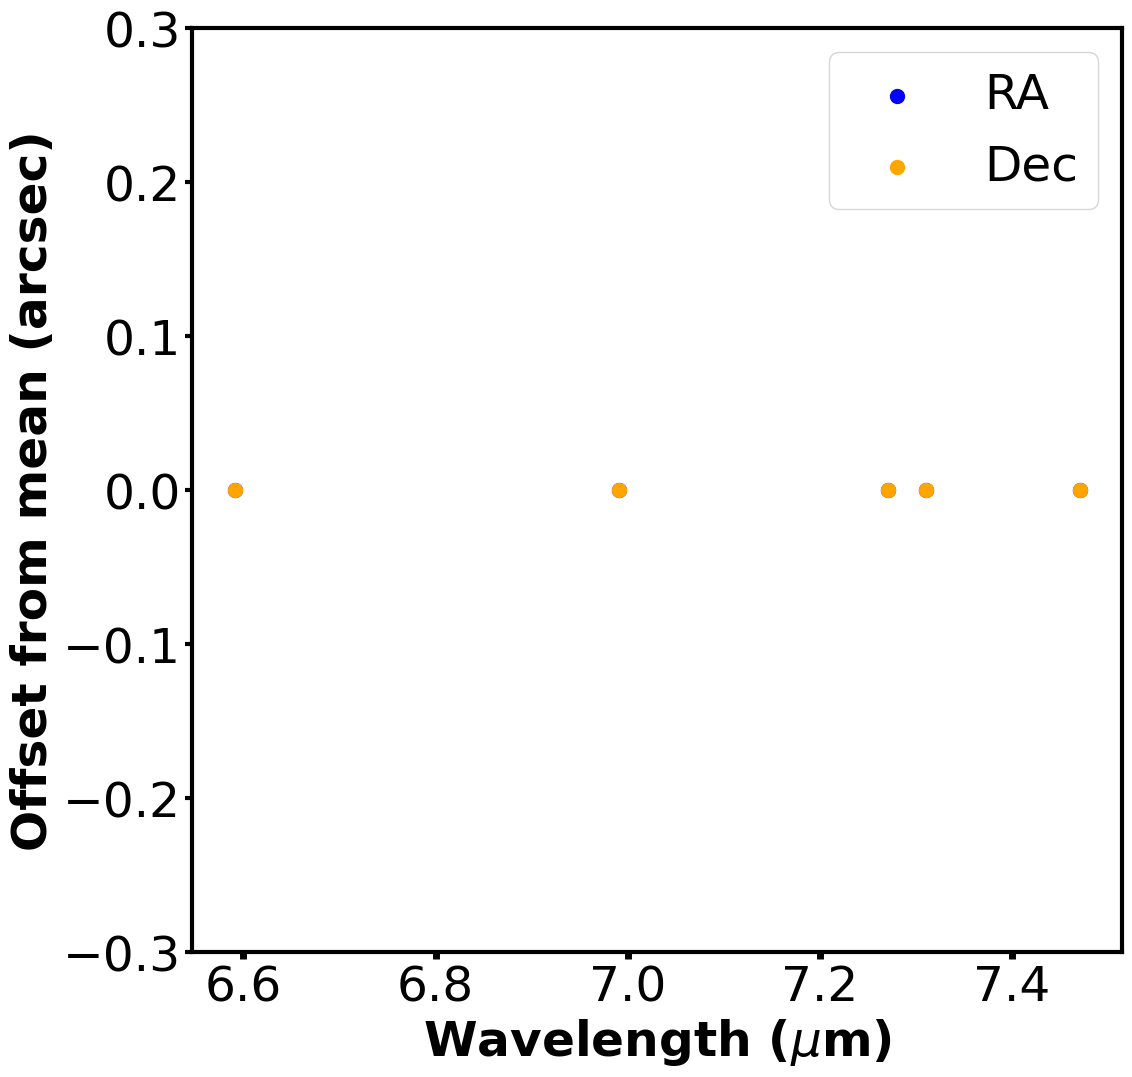

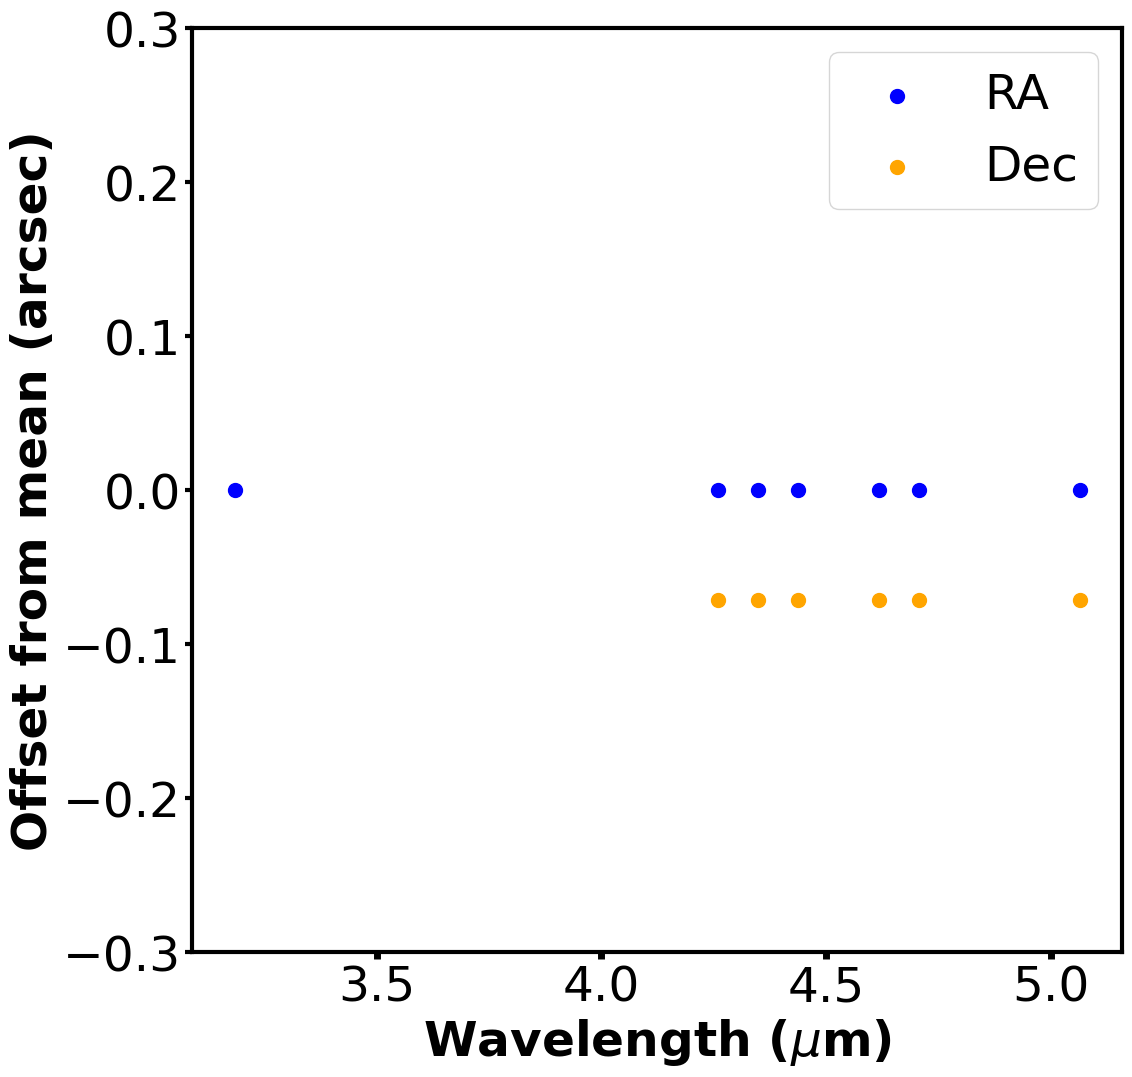

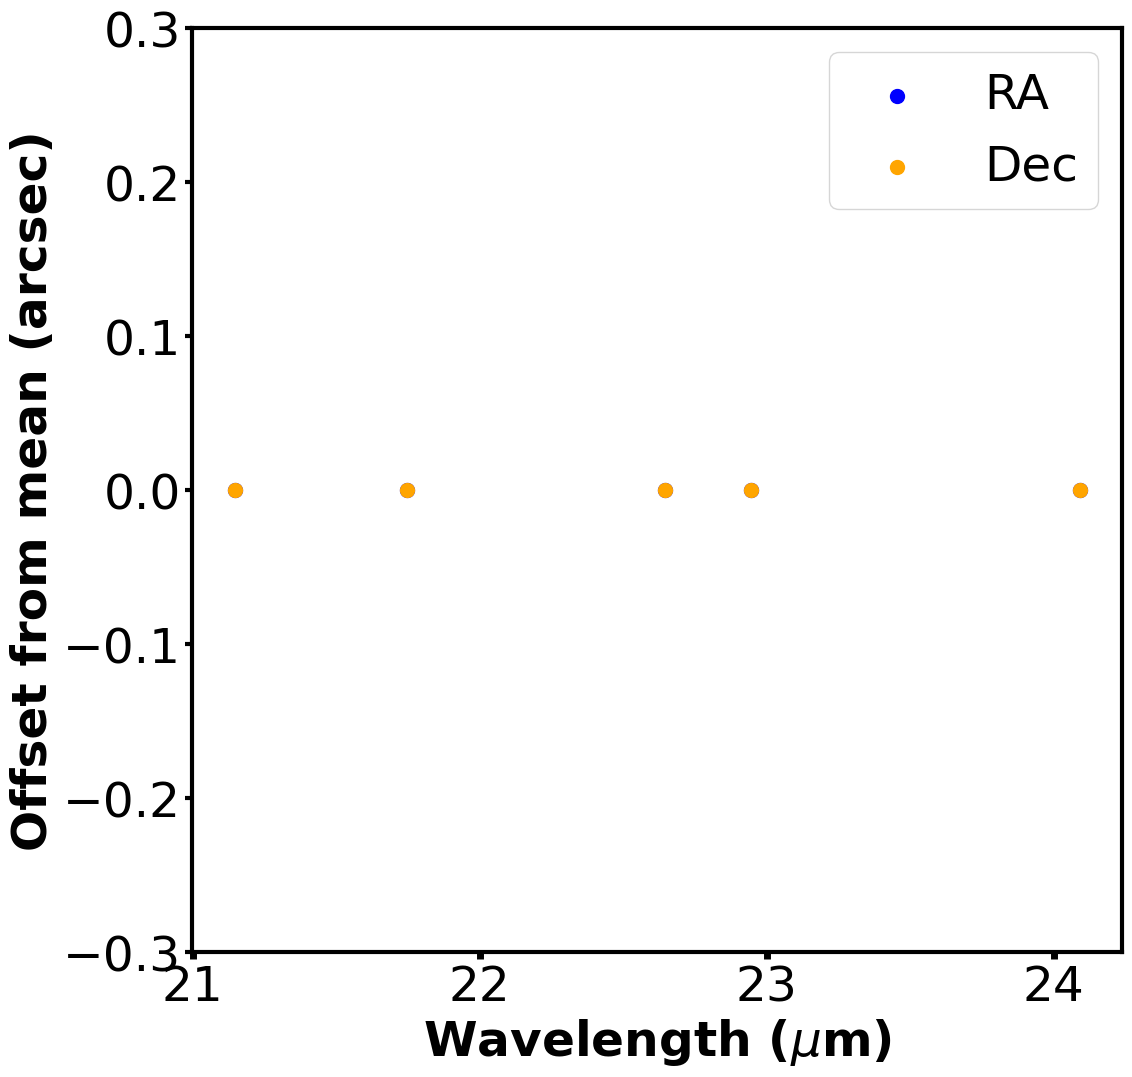

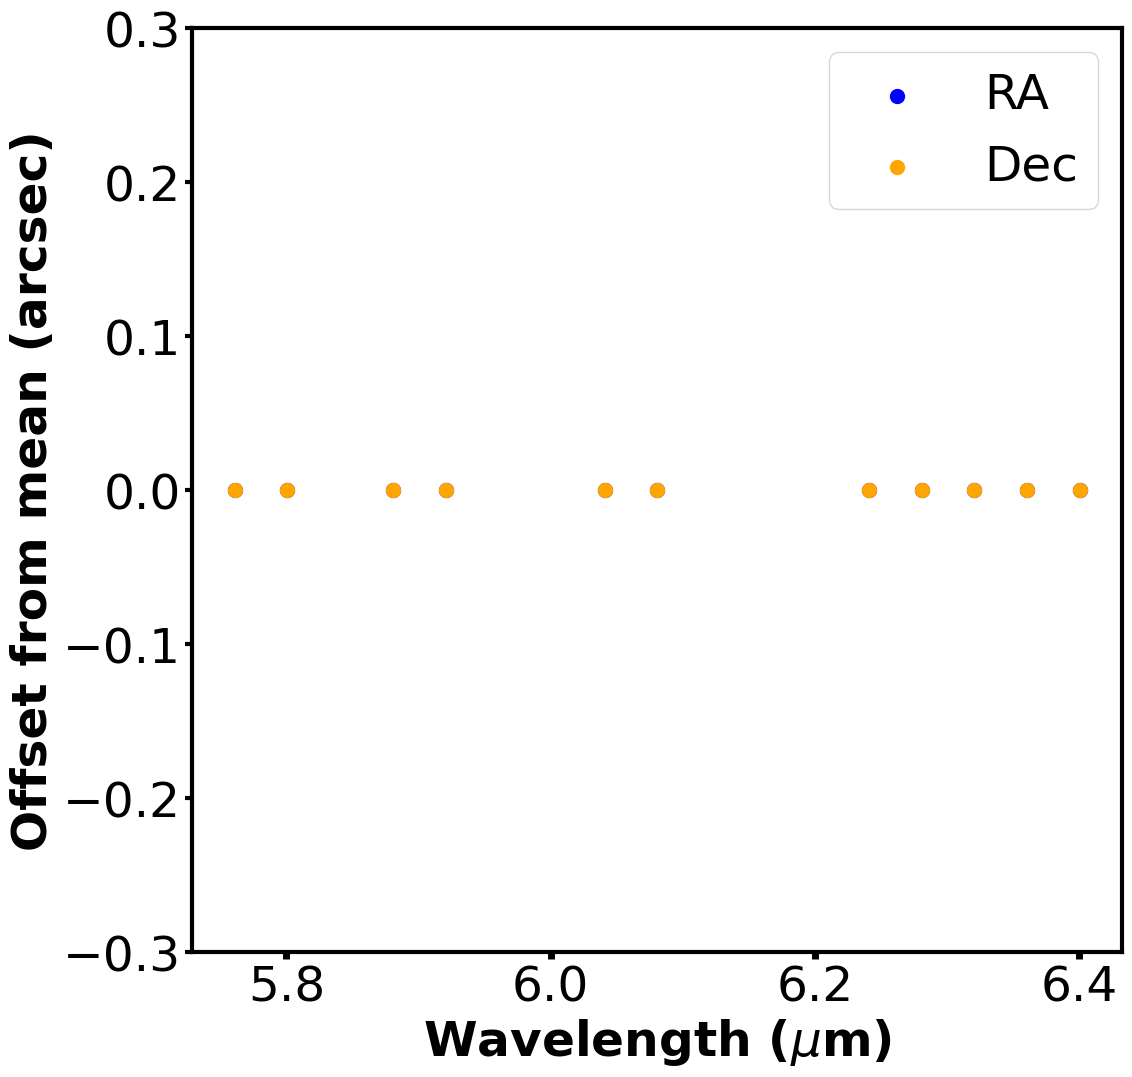

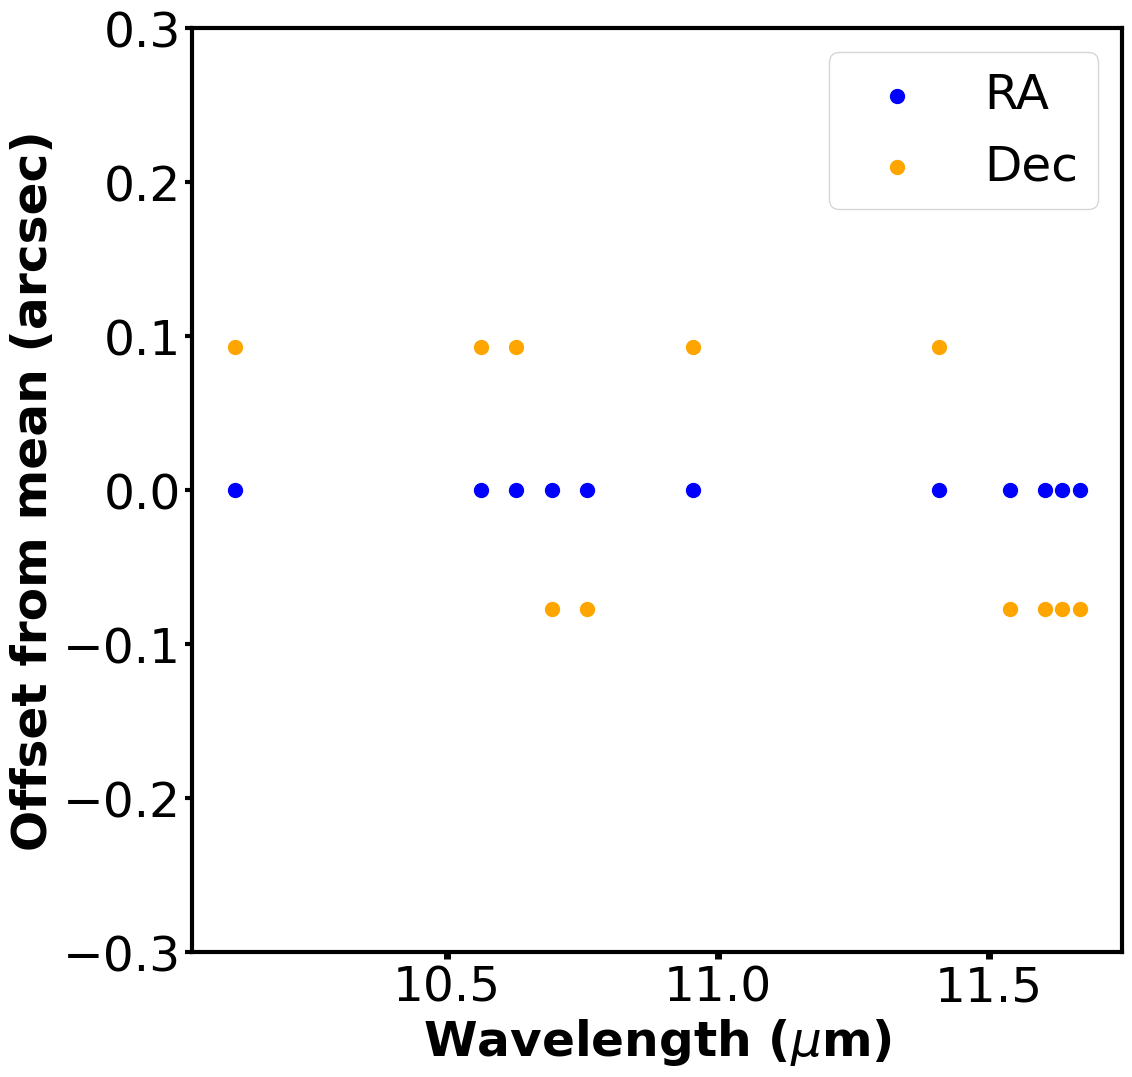

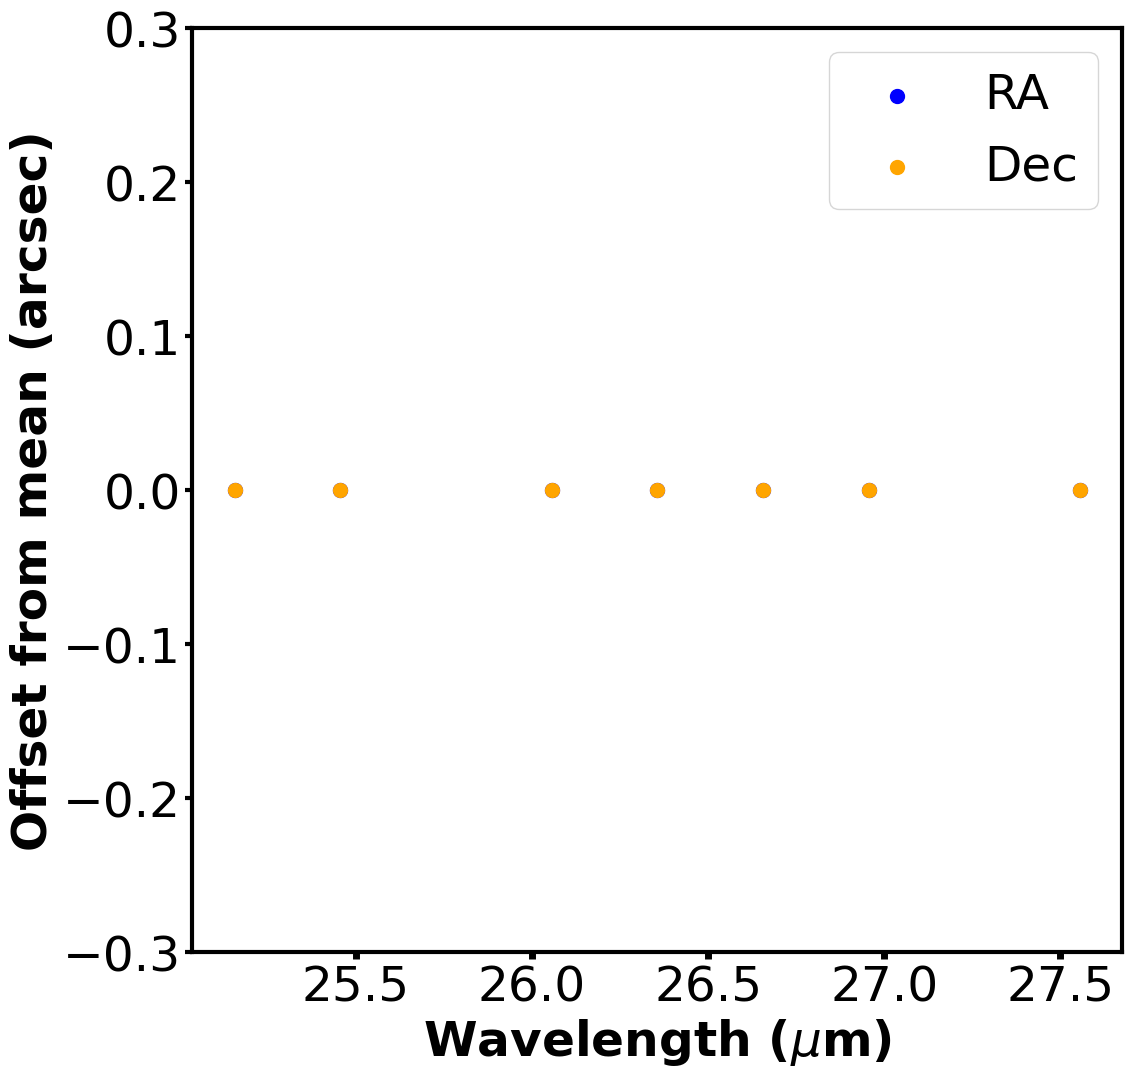

In [6]:
files=glob.glob('*s3d.fits*')
ra=[]
dec=[]
ww=[]
for file in files:
    print(file)
    ra1,dec1,ww1=pos_dif(file,150,False)
    plt.plot(ww1,ra1)
    ra.append(ra1)
    dec.append(dec1)
    ww.append(ww1)


In [7]:
(ra -np.nanmedian(ra))*3600.0

array([-1.30365811e-03,  1.92324741e-02, -3.14577467e+00,  7.51382204e-03,
                   nan, -2.93182803e-02,  1.33237782e-02,  1.30365821e-03,
        3.17098850e-02, -1.14950452e-01, -3.67746353e-03, -7.79357852e-02,
        1.22028652e-01])

In [8]:
(dec -np.nanmedian(dec))*3600.0


array([ 0.10181318, -0.12857985,  0.32842918, -0.00468603,         nan,
        0.00468603, -0.0291049 , -0.00814935,  0.13218245, -0.04936414,
        0.07263538,  0.04079281, -0.11711693])

In [9]:
offset=(((ra -np.nanmedian(ra))*3600.0)**2 + ((dec -np.nanmedian(dec))*3600.0)**2)**0.5

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_94636/3437072152.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Wavelength ($\mu$m)')
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_94636/3437072152.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Offset from mean (arcsec)')

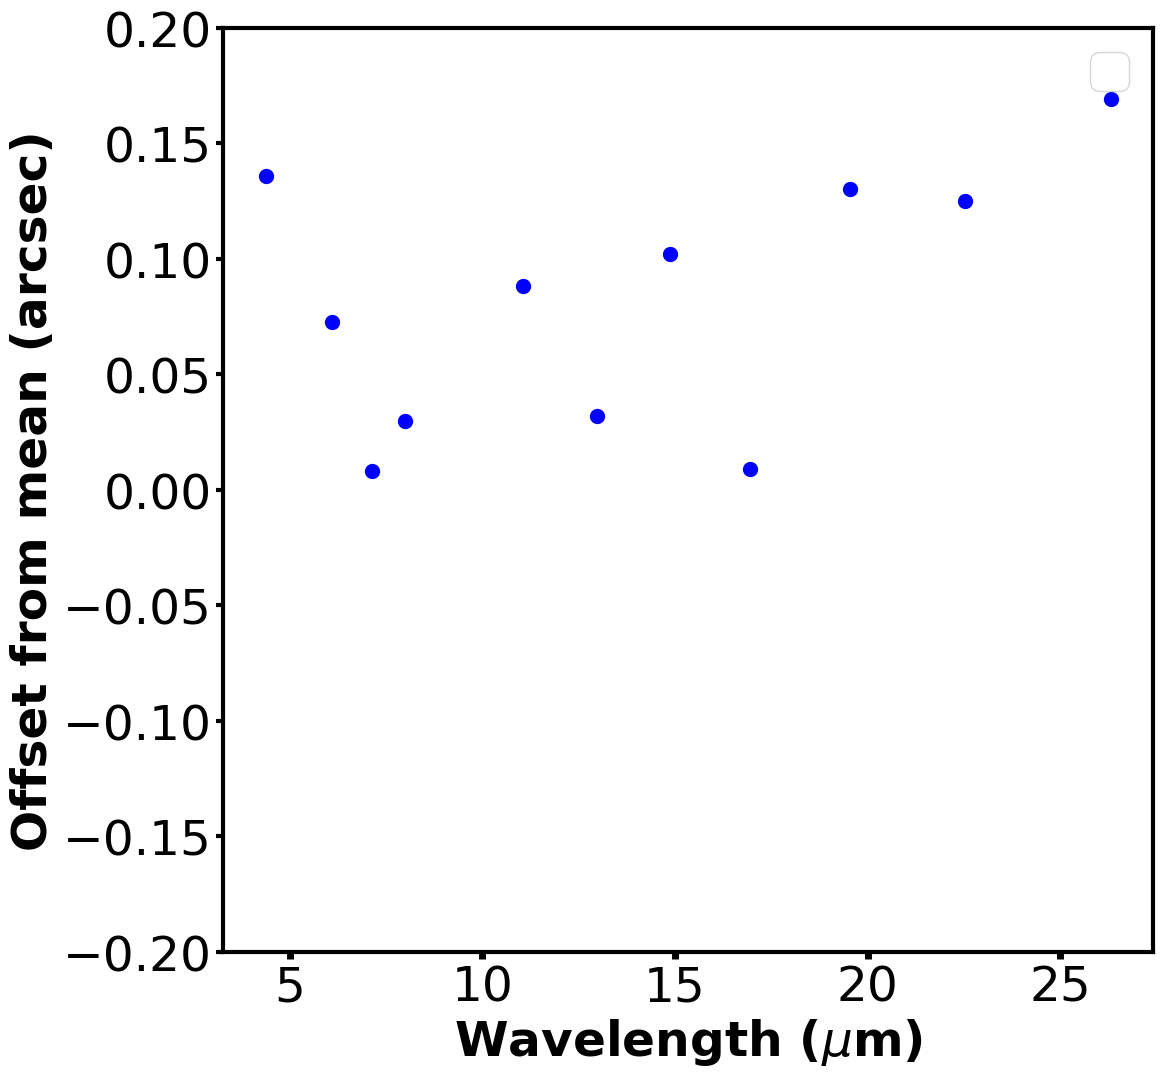

In [10]:
plt.figure(figsize=[12,12])
plt.scatter(ww,offset,s=100,c='b')
plt.legend()
plt.ylim(-0.2,0.2)
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Offset from mean (arcsec)')

In [11]:
offset
ww=np.array(ww)

In [12]:
inds = ww.argsort()
offset= offset[inds]
ww.sort()

In [13]:
ww

array([ 4.37356129,  6.09898165,  7.12680019,  7.99157801,  9.59441826,
       11.05130023, 12.98328141, 14.86343762, 16.94416648, 19.53120078,
       22.51520055, 26.31314249,         nan])

In [14]:
offset

array([0.13593276, 0.07272841, 0.00825296, 0.02969041, 3.16287274,
       0.08796613, 0.03200965, 0.10182152, 0.0088553 , 0.13001026,
       0.12510166, 0.16913712,        nan])

In [15]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Example inputs
ra_str = "16:28:21.6256529207"
dec_str = "-24:36:24.100567389"

coord = SkyCoord(ra=ra_str, dec=dec_str, unit=(u.hourangle, u.deg))

print("RA (deg):", coord.ra.deg)
print("Dec (deg):", coord.dec.deg)


RA (deg): 247.09010688716953
Dec (deg): -24.606694602052503


In [34]:
RA=247.0901026224966 
Dec= 24.606679285336597

In [36]:
(247.09010688716953 - 247.0901026224966)*3600 

0.015352822526892851

In [38]:
(-24.606694602052503 - -24.606679285336597)*3600

-0.055140177262558154

In [40]:
lam=14

In [46]:
FWHM = 0.033*lam + 0.106
print(FWHM)

0.5680000000000001
